# Theoretical Explanation and Reasoning

In financial markets, defining whether an asset is expensive or cheap on an absolute basis is generally meaningless. Valuation must instead be formulated in *relative terms*, by comparing the asset with another economically related asset. This idea underlies statistical arbitrage and relative-value trading strategies.

A common approach relies on the market beta. Given a stock and a benchmark, the beta coefficient is defined as

$$\beta = \frac{\operatorname{Cov}(R_s , R_{Benchmark})}{\operatorname{Var}(R_{Benchmark})}$$

where the numerator represents the covariance between the stock return and the benchmark return, and the denominator represents the variance of the benchmark return.
Beta corresponds to the slope coefficient of a linear regression and therefore implicitly assumes a *linear dependence structure* between returns.

For example, if $\beta = 2$ and the benchmark daily return equals $−1\%$, the model implies an expected stock return of $−2\%$. If the observed return is $−5\%$, the stock may be considered undervalued **only under the assumption that the linear model correctly describes the dependence**.

However, financial returns rarely exhibit purely linear relationships. Dependence is typically nonlinear, asymmetric, and stronger during market stress. Therefore, a more general framework is required.

---

### Copula Framework

Multivariate statistics provides such a framework through **copula functions**, which allow modeling dependence independently from marginal behavior.

Consider a continuous random vector $(X_1, X_2)$ with marginal cumulative distribution functions $(F_1)$ and $(F_2)$.
By the Probability Integral Transform:
$$U_j = F_j(X_j), \quad j = 1,2$$

then
$$U_j \sim U(0,1)$$

The joint cumulative distribution function of $(U_1, U_2)$ defines the copula:
$$C(u_1, u_2) = \mathbb{P}(U_1 \le u_1,; U_2 \le u_2)$$

Thus, the copula isolates the dependence structure from the marginal distributions.

---

### Sklar’s Theorem

Let $F(x_1,\dots,x_m)$ be a joint multivariate distribution with marginals $F_1(x_1),\dots,F_m(x_m)$.
Then there exists a copula function $C$ such that

$$F(x_1,\dots,x_m) = C\big(F_1(x_1),\dots,F_m(x_m)\big)$$

If all marginal distributions are continuous, the copula is unique.

---
### Copula types
Copula functions can be divided into two big famililies: Elliptical and Archimedian Copulas. Among the Elliptical copulas there are:

- **Gaussian**: The Gaussian Copula is a copula function where the whole dependence structure is described as a Normal and driven by the correlation between the random variables.

- **Student's t**: The Student's t copula is a copula function where the dependence structure is described as a Student's t and driven by the correlation coefficient and the number of degrees of freedom.

On the other hand, archimedian copulas are all the copula functions that can be written in the following way:

$$C\,(u_1,\,u_2,\,...,\,u_m)\,=\,ϕ^{-1}\,\big[ϕ(u_1)\,+\,ϕ(u_2)\,+\,...\,+\,ϕ(u_m)\big]$$

where **ϕ** is the generator function, which is different for every archimedian copula function and satisfies the following conditions:

- $ϕ(1)\,=\,0$
- $ϕ^{'}(t)\,<\,0, \quad\, ∀\,t\,∈\,[0,1]$
- $ϕ^{''}(t)\,>\,0, \quad\, ∀\,t\,∈\,[0,1]$

Moreover,the main difference between Archimidian and Elliptical Copulas relies on the fact that the dependency parameters are compressed into only a single parameter theta $(θ)$. Finally, Genest and Mackay, in a work published in 1986, established a link between the Kendall's tau rank correlation coefficient and the copula generator function $ϕ$ and its first order derivative $ϕ^{'}$, that is formalized as:

$$\tau\ =\ 1\,+\,4\,∫_{0}^{1}\frac{ϕ(t)}{ϕ^{'}(t)}dt$$

that allows to easily estimate the parameter in an Archimedian Copula, knowing the Kendall's tau rank measure and the generator function.

---

### Implication for Financial Modeling

Copula functions provide a flexible way to model financial dependence because they separate:

1. **Marginal behavior** (heavy tails, skewness, volatility clustering)
2. **Dependence structure** (co-movements, tail dependence, asymmetry)

In contrast to beta-based models, copulas allow the detection of relative mispricing without assuming linearity.
This makes them particularly suitable for statistical arbitrage strategies, where profits arise from temporary deviations from the equilibrium dependence structure between related assets.


# Libraries

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.distributions.copula.api import GaussianCopula
from copulas.bivariate import Frank, Gumbel, Clayton
import itertools
import pyvinecopulib as pv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 25.6 MB/s eta 0:00:00


# Data Selection

The strategy is developed across four different sectors: Semiconductors, Financials, Big Tech and Healthcare. This multiple-sector approach allows to look at the copula's adaptability to different economic regimes and different assets' dynamics.

The rationale for selecting these specific clusters resides in their unique dependence characteristics:
- **Financial Sector**: Banking and Financial stocks are historically characterized by high correlation and symmetric dependence. Then, this sector allows to verify whether a Gaussian copula is sufficient or more specific tail dependence forms are present.

- **Semiconductors**: This sectro often exhibits non-linear dynamics and extreme co-movements. Copulas are essential for capturing asymmetric tail dependence that a simple beta model would miss during rapid sector's changes.

- **Big Tech**: Large-cap technology stocks often move as a single block mainly due to common macro drivers. The copula framework helps identify when a specific pair temporarily decouples from this heavy-handed trend.

- **Healthcare**: Healthcare stocks often exhibit lower overall correlation and are more sensitive to stock-specific events (FDA approvals, patent expirations). This sector serves as a "stress test" for the model’s ability to extract signals from noisier, less-dependent pairs.

In [ ]:
sectors = {
    'Semiconductors': ['NVDA', 'AMD', 'QCOM', 'INTC', 'MU'],
    'Financials': ['JPM', 'BAC', 'GS', 'MS', 'C'],
    'Tech_Big_Cap': ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META'],
    'Healthcare': ['JNJ', 'PFE', 'ABBV', 'MRK', 'LLY']
}

all_tickers = [t for sub in sectors.values() for t in sub]
data = yf.download(all_tickers, start='2020-01-01', end='2026-01-01')['Close']
log_returns = np.log(data / data.shift(1)).dropna()

/tmp/ipython-input-3331157171.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(all_tickers, start='2020-01-01', end='2026-01-01')['Close']
[*********************100%***********************]  20 of 20 completed


# Statistical Methodology and Model Selection

The pipeline for each sector is three-fold: identification of the optimal pair, marginal distribution modeling, and copula selection via information criteria.

The optimal pair of assets is chosen taking the one having the highest **Kendall Tau** that is a non-parametric rank-based correlation measure. Despite Pearson's correlation that measures linear association, $\tau$ captures any monotonic relationship, not only linear ones, and it is less sensitive to extreme price spikes (outliers) because it is based on concordant and discordant pairs.
Moreover, as aforementioned, there is link between the Kendall's tau and the archimedian copulas parameters.

A critical step in copula modeling is the Probability Integral Transform (PIT), which requires an accurate estimation of marginal distributions to map returns onto the $U(0,1)$ domain.

Instead of a Standard Normal distribution, we assume a Student-t distribution for the marginals. In fact, financial returns exhibit higher peaks and fatter tails than a Normal distribution and, by fitting a Student-t, the model accounts for the higher probability of extreme daily moves, ensuring that the resulting $U, V$ variables are truly uniform and do not carry "residual" marginal bias into the copula fitting.

To capture diverse market dynamics, the model competes four distinct families:

- **Gaussian (Elliptical)**: Provides a benchmark of symmetric dependence with no tail dependence. It assumes that extreme decoupling events are as likely as extreme coupling events.

- **Clayton (Archimedean)**: Exhibits lower tail dependence. It is ideal for modeling "crash-o-phobia," where stocks correlate strongly during market sell-offs but decouple during rallies.

- **Gumbel (Archimedean)**: Exhibits upper tail dependence. It captures scenarios where assets move together during strong bull markets or speculative bubbles.

- **Frank (Archimedean)**: Captures symmetric dependence but, unlike the Gaussian, it is more flexible in modeling the strength of the relationship in the center of the distribution.

Finally, the model selection is governed by the Akaike Information Criterion (**AIC**):

$$AIC = 2k - 2\ln(\hat{L})$$

where $k$ is the number of parameters and $\hat{L}$ is the Maximum Likelihood estimate. Using pure Log-Likelihood ($LL$) would always favor more complex models with more parameters, leading to overfitting (capturing noise instead of signal) and the **AIC** introduces a penalty term ($2k$) for complexity. By minimizing **AIC**, the copula selected provides the best "fit-to-complexity" ratio, ensuring the model remains robust when applied to out-of-sample data.

In [ ]:
def get_best_copula_for_sector(sector_returns):
    corr_matrix = sector_returns.corr(method='kendall')
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    best_tau = upper.unstack().max()
    best_pair = upper.unstack().idxmax()

    x, y = sector_returns[best_pair[0]], sector_returns[best_pair[1]]

    # Marginals and PIT
    u = stats.t.cdf(x, *stats.t.fit(x))
    v = stats.t.cdf(y, *stats.t.fit(y))
    uv = np.column_stack([u, v])

    # Fitting and AIC
    families = [pv.BicopFamily.gaussian, pv.BicopFamily.clayton,
                pv.BicopFamily.gumbel, pv.BicopFamily.frank]

    best_aic = np.inf
    best_model = None

    for fam in families:
        obj = pv.Bicop(family=fam)
        obj.fit(uv)
        current_aic = 2 * obj.parameters.size - 2 * obj.loglik(uv)
        if current_aic < best_aic:
            best_aic = current_aic
            best_model = fam
    return best_pair, best_model, best_aic, best_tau

In [ ]:
results_summary = []

for name, tickers in sectors.items():
    sector_data = log_returns[tickers]
    pair, model, aic, tau = get_best_copula_for_sector(sector_data)

    results_summary.append({
        'Sector': name,
        'Best Pair': f"{pair[0]}-{pair[1]}",
        'Kendall Tau': round(tau,3),
        'Copula Type': str(model).split('.')[-1],
        'AIC': round(aic, 2)
    })

df_results = pd.DataFrame(results_summary)

print("--- Sector Analysis Summary ---")
print(df_results.to_string(index=False))

--- Sector Analysis Summary ---
        Sector  Best Pair  Kendall Tau Copula Type      AIC
Semiconductors   AMD-NVDA        0.545    gaussian -1168.09
    Financials      MS-GS        0.676      gumbel -2072.04
  Tech_Big_Cap GOOGL-MSFT        0.515      gumbel -1063.54
    Healthcare    MRK-JNJ        0.359      gumbel  -500.02


The summary table provides the results of the automated selection process across the four target sectors. The best pairs selected consist of: Advanced Micro Devices Inc and Nvda in the Semiconductors sector, Morgan Stanley and Goldman Sachs in the Financial sector, Google and Microsoft in the Big Tech sector and Merck & Co Inc and Johnson & Johnson in the Healthcare sector.

Several key statistical insights can be derived:

- **Dependence Strength (Kendall's tau)**: The pair exhibiting the highest degree of association ($\tau = 0.676$) belongs to the Financial sector and it consists of Morgan Stanley and Goldman Sachs. This confirms that these two companies share a deeply integrated dependence structure, making them prime candidates for statistical arbitrage.
Conversely, the pair with the lowest degree of association ($\tau = 0.359$) belongs to the Healthcare sector and it consists of Merck & Co Inc and Johnson & Johnson, suggesting that while a relationship exists, idiosyncratic risks (such as drug trial results or patent litigation) frequently decouple these assets, leading to a "noisier" signal.

- **Copula Family Selection**: A striking result is the predominancy of the Gumbel copula across three of the four sectors. This indicates the presence of upper tail dependence, implying that these pairs are more likely to move togheter during sharp market rallies. The only distinguished copula function is the Gaussian one, adapted to the Semiconductors sector suggesting a more symmetric dependence structure without significant tail asymmetries in the training period, despite the high volatility of the sector.

- **Model Fit (AIC)**: The AIC values are consistently negative and significant, with the Financials sector reaching the lowest value ($-2072.05$). This indicates a very high quality of fit. The fact that the model consistently chooses Archimedean copulas (Gumbel) over the Gaussian benchmark in most cases justifies the use of this framework: a linear model (Beta/Pearson) would have failed to capture the non-linearities identified by the AIC selection process.

---

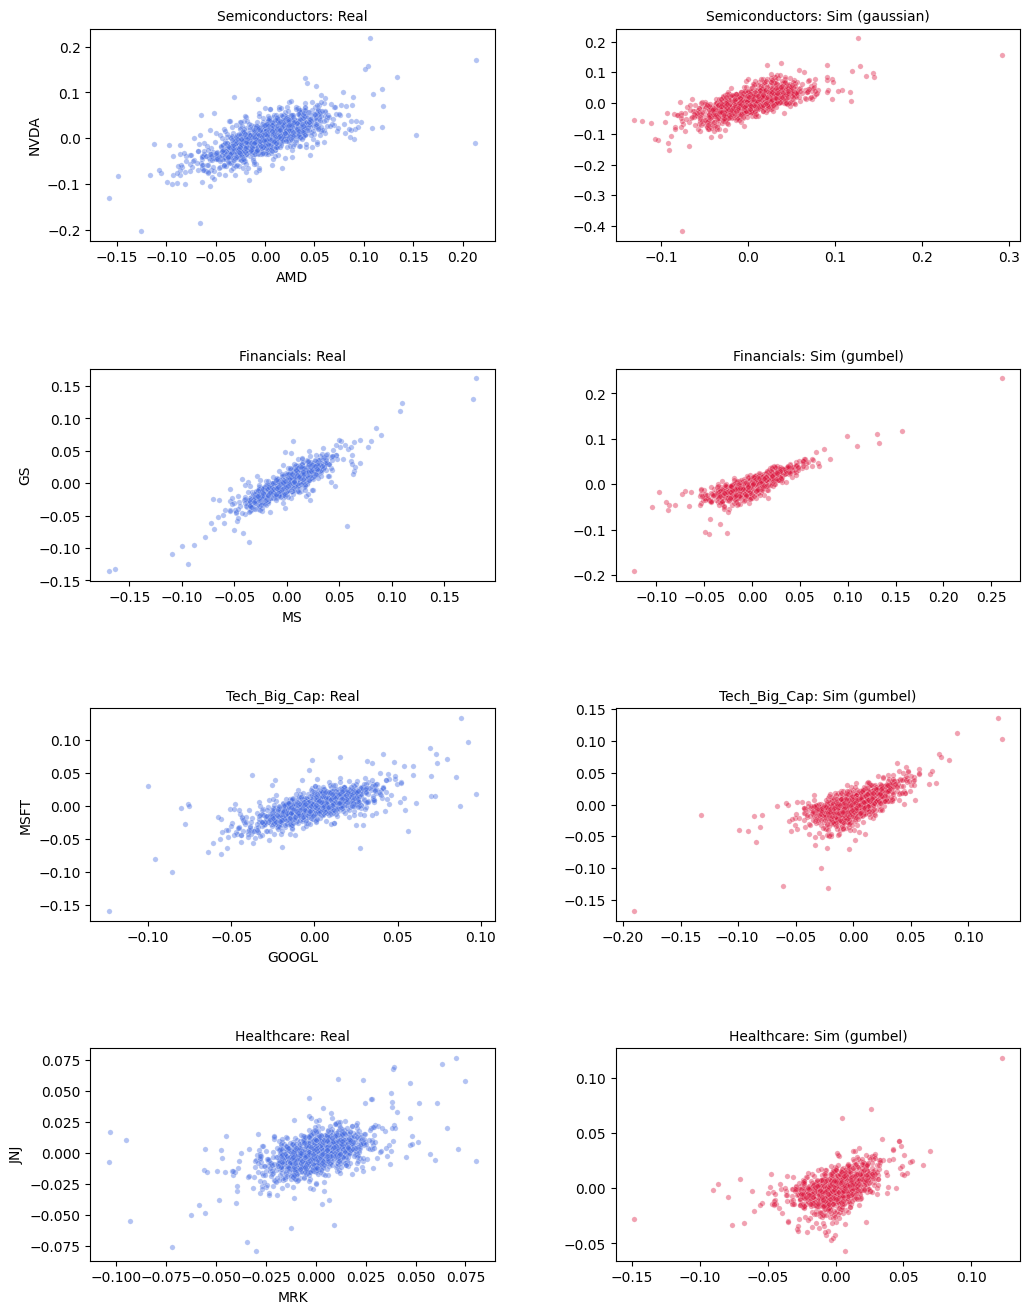

In [ ]:
def plot_sector_comparison(sectors_dict, log_returns):
    n_sectors = len(sectors_dict)
    fig, axes = plt.subplots(n_sectors, 2, figsize=(12, 4 * n_sectors))

    for i, (name, tickers) in enumerate(sectors_dict.items()):
        sector_data = log_returns[tickers]
        pair, best_fam, _ , _ = get_best_copula_for_sector(sector_data)
        x_real, y_real = sector_data[pair[0]], sector_data[pair[1]]

        u = stats.t.cdf(x_real, *stats.t.fit(x_real))
        v = stats.t.cdf(y_real, *stats.t.fit(y_real))
        uv = np.column_stack([u, v])
        bicop = pv.Bicop(family=best_fam)
        bicop.fit(uv)

        sim_uv = bicop.simulate(1500)
        x_sim = stats.t.ppf(sim_uv[:, 0], *stats.t.fit(x_real))
        y_sim = stats.t.ppf(sim_uv[:, 1], *stats.t.fit(y_real))

        sns.scatterplot(x=x_real, y=y_real, ax=axes[i, 0], alpha=0.4, color='royalblue', s=15)
        axes[i, 0].set_title(f"{name}: Real", fontsize=10)

        sns.scatterplot(x=x_sim, y=y_sim, ax=axes[i, 1], alpha=0.4, color='crimson', s=15)
        axes[i, 1].set_title(f"{name}: Sim ({str(best_fam).split('.')[-1]})", fontsize=10)

    plt.subplots_adjust(hspace=0.6, wspace=0.3)
    plt.show()

plot_sector_comparison(sectors, log_returns)

---

A visual examination of the scatter plots substantiates that the copula-based framework adeptly encapsulates the distinct dependency structure inherent to each sector, thereby circumventing the constraints imposed by simple linear correlation.

In the Semiconductors sector, the utilization of a Gaussian Copula is consistent with the observed symmetry in real data. The simulation accurately replicates the central dispersion, thereby confirming that, in this particular sample, the dependence in the tails does not exhibit significant asymmetries that would necessitate more complex models.

In the Financial and the Big Tech sectors, real data indicates a higher degree of density, accompanied by a pronounced "peak" in the upper right quadrant. Consequently, the Gumbel Copula is an appropriate model for simulating this upper tail dependence. It is observed that the red dots exhibit a propensity to "cluster" during periods of simultaneous positive rallies, thereby reflecting the tendency of these stocks to exhibit synchronized movement during bullish market phases or positive sector shocks.

A visual examination of the scatter plot for the healthcare sector reveals a greater degree of dispersion and less linearity in comparison to that of the financial sector, a discrepancy that is indicative of the lower Kendall Tau. Notwithstanding the increased noise, the Gumbel simulation successfully preserves the morphology of the actual cluster. This finding indicates that the model does not impose an imaginary correlation, but rather aligns with the weaker dependency structure characteristic of defensive stocks. In such contexts, specific risks, often idiosyncratic in nature, frequently predominate over systemic risks.

&nbsp;

# Backtesting Methodology and Trading Execution

The backtesting framework is designed to simulate the strategy's historical performance under realistic market conditions, transforming the probabilistic outputs of the copula into a discrete series of investment positions.

**1. The h-function Mapping.**

The core of the execution logic relies on the h-functions (conditional cumulative distributions). Unlike simple price-based indicators, these functions tell us the probability of an asset's return relative to its peer's movement.

- **Selection of $α$**: By setting a significance level (e.g., $0.05$), we identify "extreme" events where the assets have decoupled beyond their historical norm. From an intuitive standpoint, the higher the level of $α$ the less extreme are the events and so the higher is the number of the trades.

- **Signal Generation**: A trade is only triggered when both conditional probabilities $\big(P(U\le u|V= v)\ \text{and}\ P(V\le v|U=u)\big)$ confirm a reciprocal mispricing. This "double-gate" logic reduces false positives compared to univariate models.


**2. Position Management and Persistent Exposure**

Once a signal is triggered, the model adopts a Long-Short Neutral Position. By buying one asset and selling the other ($R_x - R_y$), the strategy seeks to isolate the "alpha" of the relationship, hedging out general market movements (systematic risk). In this implementation, positions are held until a new, contrary signal is generated. This approach assumes that once a relationship has reached an extreme, it may take time to revert to the mean, allowing the strategy to capture the full path of convergence.

**3. The Relevance of Backtesting**

This simulation serves three critical purposes:

- **Trade Frequency**: By calculating the number of trades, we can assess the strategy's turnover. A high number of trades in a low-margin relationship would warn of excessive slippage and commission costs.

- **Measuring Cumulative Edge**: Using `cumsum()` on the daily strategy returns allows us to visualize the Equity Curve. This helps identify whether profits are consistent or driven by a few lucky events.

- **Validation of the Copula Choice**:A successful backtest confirms that the copula family selected via **AIC** actually translated into profitable timing for entering and exiting pairs.



&nbsp;

In [ ]:
def backtest_copula(best_bicop_family, uv, returns_x, returns_y, alpha=0.05):
    bicop = pv.Bicop(family=best_bicop_family)
    bicop.fit(uv)
    # hfunc1 = P(U|V), hfunc2 = P(V|U)
    cond_u = bicop.hfunc1(uv)
    cond_v = bicop.hfunc2(uv)

    # Trading Logic
    signals = pd.DataFrame(index=returns_x.index)
    signals['long_x_short_y'] = (cond_u <= alpha) & (cond_v > 1-alpha)
    signals['short_x_long_y'] = (cond_u > 1-alpha) & (cond_v <= alpha)

    signals['position'] = 0
    signals.loc[signals.long_x_short_y, 'position'] = 1
    signals.loc[signals.short_x_long_y, 'position'] = -1
    signals['position'] = signals['position'].ffill().fillna(0)

    n_trades = signals['position'].diff().abs().sum()
    spread_return = returns_x - returns_y

    strategy_returns = signals['position'].shift(1) * spread_return

    return strategy_returns.cumsum(), n_trades

&nbsp;

In relative-value strategies, high turnover can easily erode profits. We assume a fixed cost per trade of $0.1\%$ ($10$ bps), applied every time the position is opened, closed, or reversed. By subtracting costs directly from the daily returns at each trade event, we account for the "drag" that commissions and slippage impose on the equity curve.

Net Profitability: This ensures that the results reported in the Total Return (Net) column reflect the actual alpha remaining after paying the price of liquidity.

The Sharpe Ratio is calculated on the net daily returns to measure the strategy’s efficiency:

$$\text{Sharpe} = \sqrt{252} \times \frac{E[R_{net}]}{\sigma_{net}}$$

A positive Sharpe Ratio indicates that the strategy's returns compensate for its volatility, whereas a negative ratio suggests that the risk taken did not yield a premium over the period.

The Maximum Drawdown (MDD) is perhaps the most vital metric for a portfolio manager. It measures the largest peak-to-trough decline in the strategy's wealth index. While the Total Return tells us where we ended up, the MDD tells us how difficult the journey was. A high value of it signals a "breakdown" in the mean-reversion assumption, highlighting the necessity of the statistical stop-loss to prevent catastrophic capital loss during periods of structural divergence.

&nbsp;

In [ ]:
performance_results = []
cost_per_trade = 0.001

def calculate_max_drawdown(cum_returns):
    wealth_index = 1 + cum_returns
    previous_peaks = wealth_index.cummax()
    drawdowns = (wealth_index - previous_peaks) / previous_peaks

    return drawdowns.min()


for name, tickers in sectors.items():
    sector_data = log_returns[tickers]
    pair, best_fam, aic, tau_val = get_best_copula_for_sector(sector_data)

    x_rets, y_rets = sector_data[pair[0]], sector_data[pair[1]]
    u = stats.t.cdf(x_rets, *stats.t.fit(x_rets))
    v = stats.t.cdf(y_rets, *stats.t.fit(y_rets))
    uv = np.column_stack([u, v])

    bicop = pv.Bicop(family=best_fam)
    bicop.fit(uv)
    cond_u, cond_v = bicop.hfunc1(uv), bicop.hfunc2(uv)

    alpha = 0.05
    pos = pd.Series(0, index=x_rets.index)
    pos[(cond_u <= alpha) & (cond_v > 1-alpha)] = 1
    pos[(cond_u > 1-alpha) & (cond_v <= alpha)] = -1
    pos = pos.ffill().fillna(0)

    daily_gross_rets = pos.shift(1) * (x_rets - y_rets)
    daily_gross_rets = daily_gross_rets.fillna(0)

    trades_mask = pos.diff().fillna(0) != 0
    n_trades = trades_mask.sum()

    daily_net_rets = daily_gross_rets.copy()
    daily_net_rets[trades_mask] -= cost_per_trade

    net_cum_returns = daily_net_rets.cumsum()

    sharpe = np.sqrt(252) * (daily_net_rets.mean() / daily_net_rets.std()) if daily_net_rets.std() != 0 else 0
    current_mdd = calculate_max_drawdown(net_cum_returns)

    performance_results.append({
        'Sector': name,
        'Best Pair': f"{pair[0]}/{pair[1]}",
        'Kendall Tau': round(tau_val, 3),
        'Copula': str(best_fam).split('.')[-1],
        'Trades': int(n_trades),
        'Total Return (Net)': f"{net_cum_returns.iloc[-1]*100:.2f}%",
        'Sharpe': round(sharpe, 2),
        'Max Drawdown': f"{current_mdd*100:.2f}%"
    })

df_perf = pd.DataFrame(performance_results)
print(df_perf)

           Sector   Best Pair  Kendall Tau    Copula  Trades  \
0  Semiconductors    AMD/NVDA        0.545  gaussian     136   
1      Financials       MS/GS        0.676    gumbel     155   
2    Tech_Big_Cap  GOOGL/MSFT        0.515    gumbel     120   
3      Healthcare     MRK/JNJ        0.359    gumbel      87   

  Total Return (Net)  Sharpe Max Drawdown  
0            -52.01%   -0.72      -68.28%  
1            -21.81%   -0.63      -26.55%  
2             10.87%    0.27      -11.04%  
3            -14.13%   -0.39      -17.10%  


The most notable result is the contrast between the Big Tech sector, which experienced a $10.87\%$ increase, and the Semiconductors sector, which experienced a $52.01\%$ decrease.

Despite the utilization of advanced technology by both entities, the Big Tech sector exhibited a phenomenon of mean reversion, characterized by the dissipation of disparities between Google and Microsoft, which were merely transient and ultimately assimilated.

In the context of semiconductors, the correlation between AMD and NVDA was found to be "broken" due to NVIDIA's parabolic trend. In the absence of a stop-loss (or with a stop-loss that was too wide), the strategy persisted in betting on the mean reversion of a spread that continued to diverge (structural trend).

With an average of $120-150$ trades per sector, transaction costs ($10$ bps) accounted for approximately $12-15\%$ of total returns.

The Financial sector, despite having the highest Kendall Tau $(0.676)$ and therefore the strongest statistical relationship, recorded the highest number of trades ($155$). This suggests that the spread is very volatile and often crosses signal thresholds, generating costs that eroded gross profit, bringing it to a net $-21.81\%$.

A notable exception is the Big Tech sector, which boasts a positive Sharpe Ratio of $0.27$, suggesting a capacity to generate value that exceeds the risk assumed.

The maximum drawdown of $-68.28\%$ in semiconductors serves as a quintessential red flag, indicating that while copulas are adept at modeling dependence, they lack the capacity to predict fundamental shifts in the business models of the implicated companies.

In summary, the findings indicate that the selection of the copula based on AIC and the selection of the pair using Kendall Tau are necessary but not sufficient conditions for profit. The efficacy of the strategy is contingent upon the nature of the spread. In the event that the divergence is attributed to statistical noise, the copula is expected to demonstrate a successful outcome. Conversely, if the divergence is attributed to a fundamental divergence, such as that observed between NVDA and AMD, the strategy necessitates a more aggressive risk management approach.